In [1]:
import matplotlib as mpl

# Increase tick label font sizes and tick length/width globally for all plots
mpl.rcParams.update({
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.size": 4,
    "ytick.minor.size": 4,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.minor.width": 1.0,
    "ytick.minor.width": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

Absolute relations and Spearman rho vs Σ_* (excluding: {'NGC4383'})
All galaxies (for color assignment): IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4383, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Galaxies used in this analysis: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698

Processing IC3392 ...
  Σ* range (95%): 7.761 to 8.936
  Spearman rho in each Σ_* bin (absolute values; 3σ clipping + trend, per galaxy):
    Bin 01 (7.86): n=433, r=N/A (no trend or too few in 3σ clipping)
    Bin 02 (8.05): n=2130, r=0.375 (p=6.39e-72)
    Bin 03 (8.25): n=5367, r=0.327 (p=2.69e-132)
    Bin 04 (8.45): n=3990, r=0.246 (p=4.64e-55)
    Bin 05 (8.64): n=1528, r=0.269 (p=2.36e-26)
    Bin 06 (8.84): n=704, r=0.094 (p=0.0131)

Processing NGC4064 ...
  Σ* range (95%): 7.213 to 9.177
  Spearman rho in each Σ_* bin (absolute values; 3σ clipping + trend, per galaxy):
    Bin 01 (7.38): n=94, r=N/A (no tre

/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_32703/1558130113.py:422: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


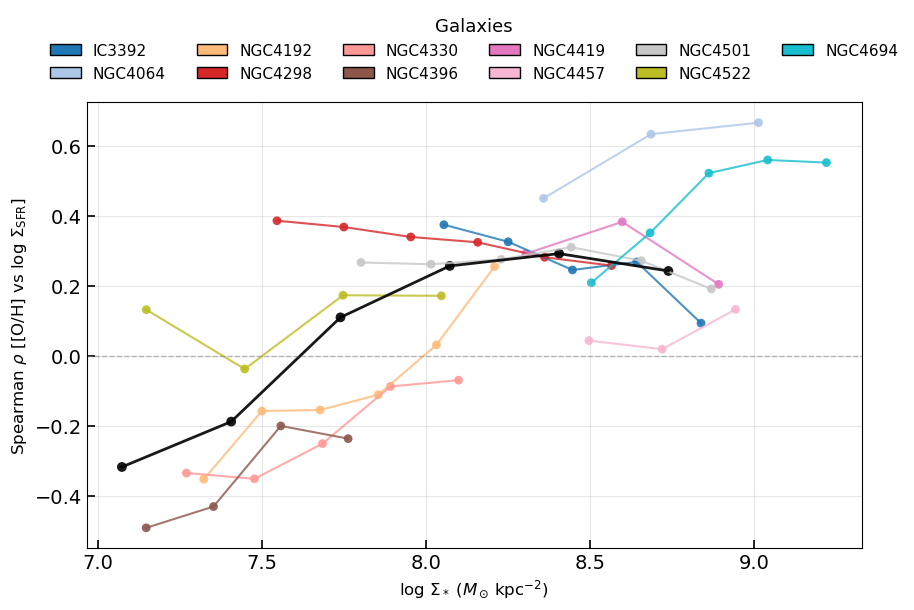

In [2]:
# ------------------------------------------------------------------
# Absolute relations: [O/H] vs log Σ_SFR in Σ_* bins
# For all galaxies (excluding NGC4383) and Spearman rho vs Σ_* summary
# Spearman rho uses only 3-sigma-clipped points and only if trend exists
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import spearmanr
from matplotlib.patches import Patch


# ------------------------------------------------------------------
# Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")

    return sigM, sigSFR, oh_map, indicator_name


# ------------------------------------------------------------------
# Helper: calculate binned statistics with unique-count requirement
# ------------------------------------------------------------------
def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_unique=20):
    """Calculate median and std in x-bins, requiring >= min_unique unique y values."""
    x_data = np.asarray(x_data)
    y_data = np.asarray(y_data)

    finite = np.isfinite(x_data) & np.isfinite(y_data)
    if np.sum(finite) == 0:
        return np.array([]), np.array([]), np.array([]), np.array([])

    x_min, x_max = np.nanmin(x_data[finite]), np.nanmax(x_data[finite])
    if not np.isfinite(x_min) or not np.isfinite(x_max) or x_min == x_max:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    if bin_edges.size < 2:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    medians = []
    stds = []
    counts = []
    valid_centers = []

    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = finite & (x_data >= bin_start) & (x_data < bin_end)
        if np.sum(in_bin) == 0:
            continue

        y_in_bin = y_data[in_bin]
        if len(np.unique(y_in_bin)) >= min_unique:
            medians.append(np.nanmedian(y_in_bin))
            stds.append(np.nanstd(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])

    return (
        np.array(valid_centers),
        np.array(medians),
        np.array(stds),
        np.array(counts),
    )


# ------------------------------------------------------------------
# Helper: unique-value 3-sigma clipping mask
# ------------------------------------------------------------------
def compute_3sigma_unique_mask(x_data, y_data, valid_mask):
    sigma_mask = np.zeros_like(valid_mask, dtype=bool)

    if np.sum(valid_mask) <= 2:
        sigma_mask[valid_mask] = True
        return sigma_mask

    try:
        x_valid = x_data[valid_mask]
        y_valid = y_data[valid_mask]

        x_unique = np.unique(x_valid)
        y_unique = np.unique(y_valid)

        x_mean = np.mean(x_unique)
        x_std = np.std(x_unique)
        y_mean = np.mean(y_unique)
        y_std = np.std(y_unique)

        if (not np.isfinite(x_std)) or (not np.isfinite(y_std)):
            sigma_mask[valid_mask] = True
            return sigma_mask

        x_lower = x_mean - 3 * x_std
        x_upper = x_mean + 3 * x_std
        y_lower = y_mean - 3 * y_std
        y_upper = y_mean + 3 * y_std

        inside = (
            (x_valid >= x_lower)
            & (x_valid <= x_upper)
            & (y_valid >= y_lower)
            & (y_valid <= y_upper)
        )
        sigma_mask[valid_mask] = inside
    except Exception:
        sigma_mask[valid_mask] = True

    return sigma_mask


# ------------------------------------------------------------------
# Galaxy list and color map (reserve color for excluded galaxy)
# ------------------------------------------------------------------
all_bin_centers = []  # Σ_* bin centers for which rho is valid (per-galaxy)
all_rho_values = []   # Spearman rho (per-galaxy)
all_galaxy_indices = []

# Also store all spaxels across galaxies to compute a global trend
global_sigM_list = []
global_sigSFR_list = []
global_oh_list = []
global_gal_index_list = []

# Build full galaxy list from available FITS files (including excluded)
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies_all = [f.name.split('_')[0] for f in bins]
excluded_galaxies = {'NGC4383'}

# Build galaxy -> color mapping over ALL galaxies (so excluded keeps its color)
galaxy_colors_all = plt.cm.tab20(np.linspace(0, 1, len(galaxies_all)))
galaxy_color_dict = dict(zip(galaxies_all, galaxy_colors_all))

# Working sample excluding NGC4383
galaxies = [g for g in galaxies_all if g not in excluded_galaxies]

print('=' * 80)
print(f"Absolute relations and Spearman rho vs Σ_* (excluding: {excluded_galaxies})")
print('All galaxies (for color assignment):', ', '.join(galaxies_all))
print('Galaxies used in this analysis:', ', '.join(galaxies))
print('=' * 80)


# ------------------------------------------------------------------
# Loop over galaxies and compute Spearman rho per Σ_* bin (per-galaxy)
# and collect global spaxels for combined trend
# ------------------------------------------------------------------
for gal_index, gal in enumerate(galaxies):
    print(f'\nProcessing {gal} ...')
    try:
        sigM, sigSFR, oh_o3n2_map, indicator_name = load_maps(gal)
    except Exception as e:
        print(f'  Skipping {gal}: {e}')
        continue

    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_sigM = np.isfinite(sigM)
    valid_all = valid_sfr & valid_oh & valid_sigM

    if np.sum(valid_all) == 0:
        print('  No valid pixels.')
        continue

    # Collect for global analysis
    global_sigM_list.append(sigM[valid_all].ravel())
    global_sigSFR_list.append(sigSFR[valid_all].ravel())
    global_oh_list.append(oh_o3n2_map[valid_all].ravel())
    global_gal_index_list.append(np.full(np.sum(valid_all), gal_index, dtype=int))

    # Define 6 Σ_* bins for this galaxy (spanning 95% population)
    n_bins = 6
    sigmaM_min = np.nanpercentile(sigM[valid_all], 2.5)
    sigmaM_max = np.nanpercentile(sigM[valid_all], 97.5)
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    sigmaM_bin_centers = 0.5 * (sigmaM_bin_edges[:-1] + sigmaM_bin_edges[1:])

    print(f'  Σ* range (95%): {sigmaM_min:.3f} to {sigmaM_max:.3f}')
    print('  Spearman rho in each Σ_* bin (absolute values; 3σ clipping + trend, per galaxy):')

    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i + 1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i + 1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i + 1]) & valid_all

        n_pixels = np.sum(bin_mask)
        if n_pixels <= 0:
            print(f'    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n=0, r=N/A')
            continue

        # Absolute values in this Σ_* bin
        sfr_bin = sigSFR[bin_mask]
        oh_bin = oh_o3n2_map[bin_mask]

        valid_corr = np.isfinite(sfr_bin) & np.isfinite(oh_bin)
        if np.sum(valid_corr) <= 2:
            print(f'    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, r=N/A (insufficient valid points)')
            continue

        # 3-sigma unique-value clipping mask
        sigma_mask = compute_3sigma_unique_mask(sfr_bin, oh_bin, valid_corr)

        # Median trend from 3-sigma-clipped points
        x_trend = sfr_bin[sigma_mask]
        y_trend = oh_bin[sigma_mask]
        centers, medians, stds, counts = calculate_binned_stats(
            x_trend,
            y_trend,
            bin_width=0.2,
            min_unique=20,
        )

        has_trend = centers.size >= 2

        if has_trend and np.sum(sigma_mask & valid_corr) > 2:
            try:
                spearman_rho, spearman_p = spearmanr(
                    sfr_bin[sigma_mask & valid_corr],
                    oh_bin[sigma_mask & valid_corr],
                )
                print(f'    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, r={spearman_rho:.3f} (p={spearman_p:.3g})')
            except Exception:
                spearman_rho = np.nan
                print(f'    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, r=N/A (error)')
        else:
            spearman_rho = np.nan
            print(f'    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, r=N/A (no trend or too few in 3σ clipping)')

        if np.isfinite(spearman_rho):
            all_bin_centers.append(sigmaM_bin_centers[i])
            all_rho_values.append(spearman_rho)
            all_galaxy_indices.append(gal_index)


# ------------------------------------------------------------------
# Prepare global arrays for combined Spearman vs Σ_* (all galaxies)
# ------------------------------------------------------------------
if global_sigM_list:
    global_sigM = np.concatenate(global_sigM_list)
    global_sigSFR = np.concatenate(global_sigSFR_list)
    global_oh = np.concatenate(global_oh_list)
else:
    global_sigM = np.array([])
    global_sigSFR = np.array([])
    global_oh = np.array([])

all_bin_centers = np.array(all_bin_centers)
all_rho_values = np.array(all_rho_values)
all_galaxy_indices = np.array(all_galaxy_indices)

print('\n' + '=' * 80)
print('Summary: number of Σ_* bins with valid Spearman rho (per galaxy):', len(all_rho_values))
print('=' * 80)


# ------------------------------------------------------------------
# Compute combined Spearman rho vs Σ_* over all galaxies (same method)
# ------------------------------------------------------------------
global_bin_centers = []
global_rho_values = []

if global_sigM.size > 0:
    n_bins_global = 6
    sigmaM_min_g = np.nanpercentile(global_sigM, 2.5)
    sigmaM_max_g = np.nanpercentile(global_sigM, 97.5)
    sigmaM_edges_g = np.linspace(sigmaM_min_g, sigmaM_max_g, n_bins_global + 1)
    sigmaM_centers_g = 0.5 * (sigmaM_edges_g[:-1] + sigmaM_edges_g[1:])

    print('\nComputing combined Spearman rho in Σ_* bins (all galaxies together)...')
    for i in range(n_bins_global):
        if i == 0:
            bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM < sigmaM_edges_g[i + 1])
        elif i == n_bins_global - 1:
            bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM <= sigmaM_edges_g[i + 1])
        else:
            bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM < sigmaM_edges_g[i + 1])

        n_pix_g = np.sum(bin_mask_g)
        if n_pix_g <= 0:
            print(f'  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n=0, r=N/A')
            continue

        sfr_bin_g = global_sigSFR[bin_mask_g]
        oh_bin_g = global_oh[bin_mask_g]

        valid_corr_g = np.isfinite(sfr_bin_g) & np.isfinite(oh_bin_g)
        if np.sum(valid_corr_g) <= 2:
            print(f'  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, r=N/A (insufficient valid points)')
            continue

        sigma_mask_global = compute_3sigma_unique_mask(sfr_bin_g, oh_bin_g, valid_corr_g)

        x_trend_g = sfr_bin_g[sigma_mask_global]
        y_trend_g = oh_bin_g[sigma_mask_global]
        centers_g, medians_g, stds_g, counts_g = calculate_binned_stats(
            x_trend_g,
            y_trend_g,
            bin_width=0.2,
            min_unique=20,
        )

        has_trend_g = centers_g.size >= 3

        if has_trend_g and np.sum(sigma_mask_global & valid_corr_g) > 2:
            try:
                rho_g, p_g = spearmanr(
                    sfr_bin_g[sigma_mask_global & valid_corr_g],
                    oh_bin_g[sigma_mask_global & valid_corr_g],
                )
                global_bin_centers.append(sigmaM_centers_g[i])
                global_rho_values.append(rho_g)
                print(f'  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, r={rho_g:.3f} (p={p_g:.3g})')
            except Exception:
                print(f'  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, r=N/A (error)')
        else:
            print(f'  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, r=N/A (no trend or too few in 3σ clipping)')

global_bin_centers = np.array(global_bin_centers)
global_rho_values = np.array(global_rho_values)


# ------------------------------------------------------------------
# Plot Spearman rho vs Σ_* for all galaxies, with galaxy color legend
# and an additional combined (all galaxies) trend in black
# ------------------------------------------------------------------
if len(all_rho_values) > 0:
    galaxy_indices_unique = np.unique(all_galaxy_indices)

    fig = plt.figure(figsize=(10, 7))
    gs = gridspec.GridSpec(2, 1, height_ratios=[0.18, 1.0], hspace=0.05)
    legend_ax = fig.add_subplot(gs[0, 0])
    ax = fig.add_subplot(gs[1, 0])
    legend_ax.axis('off')

    plotted_galaxies = []

    for idx in galaxy_indices_unique:
        mask = all_galaxy_indices == idx
        gal_name = galaxies[idx]
        color = galaxy_color_dict[gal_name]

        x_vals = all_bin_centers[mask]
        y_vals = all_rho_values[mask]

        if len(x_vals) <= 1:
            continue

        plotted_galaxies.append(gal_name)

        order = np.argsort(x_vals)
        x_sorted = x_vals[order]
        y_sorted = y_vals[order]

        ax.plot(x_sorted, y_sorted, color=color, linewidth=1.5, alpha=0.8)
        ax.scatter(x_sorted, y_sorted, color=color, s=40, alpha=0.9, edgecolors='none', rasterized=True)

    if global_rho_values.size > 0:
        order_g = np.argsort(global_bin_centers)
        ax.plot(
            global_bin_centers[order_g],
            global_rho_values[order_g],
            color='black',
            linewidth=2.0,
            alpha=0.9,
            linestyle='-',
        )
        ax.scatter(
            global_bin_centers[order_g],
            global_rho_values[order_g],
            color='black',
            s=50,
            alpha=0.9,
            edgecolors='none',
            rasterized=True,
        )

    ax.axhline(0.0, color='gray', linestyle='--', linewidth=1.0, alpha=0.5)
    ax.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
    ax.set_ylabel(r'Spearman $\rho$ [[O/H] vs $\log\,\Sigma_{\mathrm{SFR}}$]', fontsize=12)
    ax.grid(True, alpha=0.3)

    legend_elements = [
        Patch(facecolor=galaxy_color_dict[gal], edgecolor='black', label=gal)
        for gal in plotted_galaxies
    ]
    if len(plotted_galaxies) > 0:
        legend_ax.legend(
            handles=legend_elements,
            loc='center',
            ncol=min(len(plotted_galaxies), 6),
            frameon=False,
            fontsize=11,
            title='Galaxies',
            title_fontsize=13,
        )

    plt.tight_layout()
    plt.show()
else:
    print('No valid Spearman rho values to plot.')

In [ ]:
# ------------------------------------------------------------------
# 2x2 Combined figure: absolute maps + Moran-like map + binned Σ* map
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gs_module
from matplotlib.colors import BoundaryNorm, SymLogNorm
import matplotlib.ticker as mticker
from matplotlib.ticker import ScalarFormatter

# Only focus on NGC4501 for this visualisation
galaxies = ['NGC4501']

# ------------------------------------------------------------------
# Define threshold parameter for linear/log colorbar transition and classification
# ------------------------------------------------------------------
threshold = 1  # Values between -threshold and +threshold use linear scale

# ------------------------------------------------------------------
# 1.  Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        binid_map = h_spatial['BINID'].data
        wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
        gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
    return sigM, sigSFR, oh_map, indicator_name, wcs, gas_header, binid_map

for gal in galaxies:
    sigM, sigSFR, oh_o3n2_map, indicator_name, wcs_full, gas_header, binid_map = load_maps(gal)
    # Valid pixels across maps
    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_sigM = np.isfinite(sigM)
    valid_all = valid_sfr & valid_oh & valid_sigM

    # ------------------------------------------------------------------
    # 2.  Use absolute maps directly
    # ------------------------------------------------------------------
    # Define 12 Σ* bins (still used for the binned Σ* panel)
    n_bins = 12
    sigmaM_min = np.nanmin(sigM[valid_all])
    sigmaM_max = np.nanmax(sigM[valid_all])
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)

    # Absolute display limits
    sfr_abs_min = np.nanmin(sigSFR[valid_sfr])
    sfr_abs_max = np.nanmax(sigSFR[valid_sfr])
    oh_abs_min = np.nanmin(oh_o3n2_map[valid_oh])
    oh_abs_max = np.nanmax(oh_o3n2_map[valid_oh])

    # ------------------------------------------------------------------
    # 3.  Calculate local bivariate Moran-like map (from absolute maps)
    # ------------------------------------------------------------------
    def local_bivariate_moran_by_bin(A, B, valid_mask, binid_map, neighbourhood='queen'):
        """Local bivariate Moran-style statistic on adjacent spatial bins.

        Each valid BINID is treated as one graph node, using the mean A and B value
        of that bin. The resulting per-bin Moran value is expanded back to all
        valid pixels in the bin for plotting.
        """
        A = np.asarray(A, dtype=float)
        B = np.asarray(B, dtype=float)
        valid_mask = np.asarray(valid_mask, dtype=bool)
        binid_raw = np.asarray(binid_map, dtype=float)
        if A.shape != B.shape or A.shape != valid_mask.shape or A.shape != binid_raw.shape:
            raise ValueError('A, B, valid_mask, and binid_map must have the same shape')

        I_map = np.full(A.shape, np.nan)
        quad_map = np.zeros(A.shape, dtype=np.int16)
        finite_bin = np.isfinite(binid_raw) & (binid_raw >= 0)
        binid = np.full(A.shape, -1, dtype=np.int64)
        binid[finite_bin] = np.rint(binid_raw[finite_bin]).astype(np.int64)
        valid = valid_mask & np.isfinite(A) & np.isfinite(B) & (binid >= 0)
        valid_bins = np.unique(binid[valid])
        if valid_bins.size < 2:
            return I_map, quad_map

        max_bin = int(valid_bins.max())
        flat_bins = binid[valid].ravel()
        counts = np.bincount(flat_bins, minlength=max_bin + 1).astype(float)
        sum_A = np.bincount(flat_bins, weights=A[valid].ravel(), minlength=max_bin + 1)
        sum_B = np.bincount(flat_bins, weights=B[valid].ravel(), minlength=max_bin + 1)
        A_bin = np.full(max_bin + 1, np.nan)
        B_bin = np.full(max_bin + 1, np.nan)
        has_data = counts > 0
        A_bin[has_data] = sum_A[has_data] / counts[has_data]
        B_bin[has_data] = sum_B[has_data] / counts[has_data]

        A_vals = A_bin[valid_bins]
        B_vals = B_bin[valid_bins]
        A_std = np.nanstd(A_vals)
        B_std = np.nanstd(B_vals)
        if not np.isfinite(A_std) or not np.isfinite(B_std) or A_std == 0 or B_std == 0:
            return I_map, quad_map

        Az = np.full(max_bin + 1, np.nan)
        Bz = np.full(max_bin + 1, np.nan)
        Az[valid_bins] = (A_vals - np.nanmean(A_vals)) / A_std
        Bz[valid_bins] = (B_vals - np.nanmean(B_vals)) / B_std

        offsets = [(-1, 0), (1, 0), (0, -1), (0, 1)]
        if neighbourhood == 'queen':
            offsets += [(-1, -1), (-1, 1), (1, -1), (1, 1)]
        elif neighbourhood != 'rook':
            raise ValueError("neighbourhood must be 'rook' or 'queen'")

        adjacency = {int(b): set() for b in valid_bins}
        rows, cols = A.shape
        for dy, dx in offsets:
            y0 = max(0, -dy)
            y1 = rows - max(0, dy)
            x0 = max(0, -dx)
            x1 = cols - max(0, dx)
            src = (slice(y0, y1), slice(x0, x1))
            dst = (slice(y0 + dy, y1 + dy), slice(x0 + dx, x1 + dx))
            pair_valid = valid[src] & valid[dst] & (binid[src] != binid[dst])
            for left, right in zip(binid[src][pair_valid], binid[dst][pair_valid]):
                left = int(left)
                right = int(right)
                adjacency[left].add(right)
                adjacency[right].add(left)

        for b in valid_bins:
            b = int(b)
            neigh = sorted(adjacency[b])
            if not neigh:
                continue
            lag_B = np.nanmean(Bz[neigh])
            I_val = Az[b] * lag_B
            pixels = valid & (binid == b)
            I_map[pixels] = I_val
            if Az[b] >= 0 and lag_B >= 0:
                quad_map[pixels] = 1
            elif Az[b] < 0 and lag_B < 0:
                quad_map[pixels] = 2
            elif Az[b] >= 0 and lag_B < 0:
                quad_map[pixels] = 3
            else:
                quad_map[pixels] = 4

        return I_map, quad_map
    I_map, quad_map = local_bivariate_moran_by_bin(sigSFR, oh_o3n2_map, valid_all, binid_map,
                                            neighbourhood='queen')

    # ------------------------------------------------------------------
    # Calculate statistics for three classes based on threshold
    # ------------------------------------------------------------------
    valid_I = np.isfinite(I_map)
    n_total = np.sum(valid_I)
    n_high = np.sum(I_map[valid_I] > threshold)
    n_mid = np.sum((I_map[valid_I] >= -threshold) & (I_map[valid_I] <= threshold))
    n_low = np.sum(I_map[valid_I] < -threshold)
    pct_high = (n_high / n_total * 100) if n_total > 0 else 0
    pct_mid = (n_mid / n_total * 100) if n_total > 0 else 0
    pct_low = (n_low / n_total * 100) if n_total > 0 else 0

    # ------------------------------------------------------------------
    # 4.  Create binned Σ* map
    # ------------------------------------------------------------------
    sigM_binned_map = np.full_like(sigM, np.nan)

    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all

        # Assign bin center value
        bin_center = (sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2
        sigM_binned_map[bin_mask] = bin_center

    # ------------------------------------------------------------------
    # 5.  Prepare coordinate extent
    # ------------------------------------------------------------------
    wcs_celestial = WCS(gas_header).celestial
    y_size, x_size = sigSFR.shape
    x_coords = np.arange(x_size)
    y_coords = np.arange(y_size)
    xx, yy = np.meshgrid(x_coords, y_coords)
    ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
    extent = [ra.max(), ra.min(), dec.min(), dec.max()]

    # ------------------------------------------------------------------
    # 5b.  Scale bar: 1 kpc for 0.2 arcsec/pixel at 16.5 Mpc
    # ------------------------------------------------------------------
    pix_scale_arcsec = 0.2
    distance_mpc = 16.5
    kpc_arcsec = 206265.0 / (distance_mpc * 1000.0)
    scalebar_length_deg = kpc_arcsec / 3600.0

    def add_scalebar(ax, length_deg, label='1 kpc'):
        x0, x1 = ax.get_xlim()
        x_range = abs(x1 - x0)
        if x_range == 0:
            return
        frac_len = length_deg / x_range
        x_start = 0.05
        y_start = 0.95
        x_end = x_start + frac_len
        line, = ax.plot([x_start, x_end], [y_start, y_start], transform=ax.transAxes,
                        color='k', lw=3, clip_on=False)
        line.set_in_layout(False)
        txt = ax.text((x_start + x_end) / 2, y_start - 0.03, label,
                      transform=ax.transAxes, ha='center', va='top', color='k')
        txt.set_in_layout(False)

    # ------------------------------------------------------------------
    # 6.  2x2 figure: shared axes, equal aspect preserved, colorbars glued to axes
    # ------------------------------------------------------------------
    from mpl_toolkits.axes_grid1 import make_axes_locatable

    # Auto-derive a reasonable figsize from the map extent
    dx = abs(extent[1] - extent[0])   # RA span
    dy = abs(extent[3] - extent[2])   # Dec span
    data_ratio = (dx / dy) if dy > 0 else 1.0  # width / height

    panel_h = 4.2   # inches per panel height (tune once)
    panel_w = panel_h * data_ratio
    cbar_w = 0.35   # inches per colorbar (tune once)

    W = 2 * panel_w + 2 * cbar_w + 1.2
    H = 2 * panel_h + 0.8

    fig, axs = plt.subplots(
        2, 2, figsize=(W, H), sharex=True, sharey=True
    )

    # Make space for the appended colorbars (right margin matters)
    fig.subplots_adjust(
        left=0.07, right=0.96, bottom=0.07, top=0.98,
        wspace=0.20, hspace=0.06
    )

    ax1, ax2 = axs[0, 0], axs[0, 1]
    ax3, ax4 = axs[1, 0], axs[1, 1]

    def add_cbar(ax, im, label, size="3.5%", pad=0.02, labelpad=6, labelsize=11):
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size=size, pad=pad)
        cbar = fig.colorbar(im, cax=cax)
        cbar.set_label(label, fontsize=labelsize, labelpad=labelpad)
        return cbar

    # --- Ticks / formatting (readable RA, no +1.834e2)
    for ax in (ax1, ax2, ax3, ax4):
        ax.xaxis.set_major_locator(mticker.MaxNLocator(3))
        ax.yaxis.set_major_locator(mticker.MaxNLocator(5))
        ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

    # Hide inner tick labels
    plt.setp(ax1.get_xticklabels(), visible=False)
    plt.setp(ax2.get_xticklabels(), visible=False)
    plt.setp(ax2.get_yticklabels(), visible=False)
    plt.setp(ax4.get_yticklabels(), visible=False)

    # Axis labels (outer only)
    ax3.set_xlabel("RA (deg)", fontsize=16)
    ax4.set_xlabel("RA (deg)", fontsize=16)
    ax1.set_ylabel("Dec (deg)", fontsize=16)
    ax3.set_ylabel("Dec (deg)", fontsize=16)

    # ---- Panel 1: absolute log Σ_SFR
    im_sfr = ax1.imshow(
        np.ma.masked_invalid(sigSFR),
        origin="lower", cmap="coolwarm",
        extent=extent, vmin=sfr_abs_min, vmax=sfr_abs_max,
        aspect="equal"
    )
    add_scalebar(ax1, scalebar_length_deg, label="1 kpc")
    add_cbar(ax1, im_sfr, r'$\log\,\Sigma_{\mathrm{SFR}}\;(M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', labelpad=4)

    # ---- Panel 2: absolute [O/H]
    im_oh = ax2.imshow(
        np.ma.masked_invalid(oh_o3n2_map),
        origin="lower", cmap="coolwarm",
        extent=extent, vmin=oh_abs_min, vmax=oh_abs_max,
        aspect="equal"
    )
    add_cbar(ax2, im_oh, r'[O/H]')

    # ---- Panel 3: Moran-like
    vI = np.nanmax(np.abs(I_map))
    norm = SymLogNorm(linthresh=threshold, linscale=1.0, vmin=-vI, vmax=vI, base=10)

    imI = ax3.imshow(
        np.ma.masked_invalid(I_map),
        origin="lower", cmap="coolwarm",
        extent=extent, norm=norm,
        aspect="equal"
    )
    cbarI = add_cbar(
        ax3, imI,
        r'$z(\log\Sigma_{\rm SFR}) \times z_{\rm lag}({\rm [O/H]})$'
    )

    # Keep your symmetric-log ticks logic
    max_pow = int(np.floor(np.log10(vI))) if vI > 0 else 0
    pos_ticks = [10**k for k in range(0, max_pow + 1) if 10**k <= vI]
    pos_ticks_filtered = [p for p in pos_ticks if p != threshold]
    neg_ticks_filtered = [-p for p in reversed(pos_ticks_filtered)]
    ticks = sorted(set(neg_ticks_filtered + [-threshold, 0.0, threshold] + pos_ticks_filtered))
    cbarI.set_ticks(ticks)
    cbarI.set_ticklabels([f"{t:g}" for t in ticks])

    legend_text = (
        rf'$I_i > {threshold}$: {pct_high:.1f}% (N={n_high})'
        '\n' + rf'$|I_i| \leq {threshold}$: {pct_mid:.1f}% (N={n_mid})'
        '\n' + rf'$I_i < -{threshold}$: {pct_low:.1f}% (N={n_low})'
    )
    ax3.text(
        0.98, 0.02, legend_text, transform=ax3.transAxes,
        fontsize=10, va="bottom", ha="right",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
    )

    # ---- Panel 4: binned Σ*
    cmap_discrete = plt.cm.inferno
    norm_discrete = BoundaryNorm(sigmaM_bin_edges, cmap_discrete.N)

    im_sigM_binned = ax4.imshow(
        np.ma.masked_invalid(sigM_binned_map),
        origin="lower", cmap=cmap_discrete, norm=norm_discrete,
        extent=extent,
        aspect="equal"
    )
    cbar_binned = add_cbar(
        ax4, im_sigM_binned,
        r'$\log\,\Sigma_*\;(M_\odot\,\mathrm{kpc}^{-2})$'
    )

    bin_centers = [(sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2 for i in range(n_bins)]
    cbar_binned.set_ticks(bin_centers)
    cbar_binned.set_ticklabels([f"{bc:.2f}" for bc in bin_centers])

    # fig.savefig(f'Plot_Paper_1/{gal}_correlation_map_moran.png', dpi=600, bbox_inches="tight", pad_inches=0.02)
    # fig.savefig(f'Plot_Paper_1/{gal}_correlation_map_moran.pdf', bbox_inches="tight", pad_inches=0.02)
    plt.show()

In [ ]:
# ------------------------------------------------------------------
# 2x2 Combined figure: absolute maps + Moran-like map + binned Σ* map
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gs_module
from matplotlib.colors import BoundaryNorm, SymLogNorm
import matplotlib.ticker as mticker
from matplotlib.ticker import ScalarFormatter

# Only focus on NGC4192 for this visualisation
galaxies = ['NGC4192']

# ------------------------------------------------------------------
# Define threshold parameter for linear/log colorbar transition and classification
# ------------------------------------------------------------------
threshold = 1  # Values between -threshold and +threshold use linear scale

# ------------------------------------------------------------------
# 1.  Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        binid_map = h_spatial['BINID'].data
        wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
        gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
    return sigM, sigSFR, oh_map, indicator_name, wcs, gas_header, binid_map

for gal in galaxies:
    sigM, sigSFR, oh_o3n2_map, indicator_name, wcs_full, gas_header, binid_map = load_maps(gal)
    # Valid pixels across maps
    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_sigM = np.isfinite(sigM)
    valid_all = valid_sfr & valid_oh & valid_sigM

    # ------------------------------------------------------------------
    # 2.  Use absolute maps directly
    # ------------------------------------------------------------------
    # Define 12 Σ* bins (still used for the binned Σ* panel)
    n_bins = 12
    sigmaM_min = np.nanmin(sigM[valid_all])
    sigmaM_max = np.nanmax(sigM[valid_all])
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)

    # Absolute display limits
    sfr_abs_min = np.nanmin(sigSFR[valid_sfr])
    sfr_abs_max = np.nanmax(sigSFR[valid_sfr])
    oh_abs_min = np.nanmin(oh_o3n2_map[valid_oh])
    oh_abs_max = np.nanmax(oh_o3n2_map[valid_oh])

    # ------------------------------------------------------------------
    # 3.  Calculate local bivariate Moran-like map (from absolute maps)
    # ------------------------------------------------------------------
    def local_bivariate_moran_by_bin(A, B, valid_mask, binid_map, neighbourhood='queen'):
        """Local bivariate Moran-style statistic on adjacent spatial bins.

        Each valid BINID is treated as one graph node, using the mean A and B value
        of that bin. The resulting per-bin Moran value is expanded back to all
        valid pixels in the bin for plotting.
        """
        A = np.asarray(A, dtype=float)
        B = np.asarray(B, dtype=float)
        valid_mask = np.asarray(valid_mask, dtype=bool)
        binid_raw = np.asarray(binid_map, dtype=float)
        if A.shape != B.shape or A.shape != valid_mask.shape or A.shape != binid_raw.shape:
            raise ValueError('A, B, valid_mask, and binid_map must have the same shape')

        I_map = np.full(A.shape, np.nan)
        quad_map = np.zeros(A.shape, dtype=np.int16)
        finite_bin = np.isfinite(binid_raw) & (binid_raw >= 0)
        binid = np.full(A.shape, -1, dtype=np.int64)
        binid[finite_bin] = np.rint(binid_raw[finite_bin]).astype(np.int64)
        valid = valid_mask & np.isfinite(A) & np.isfinite(B) & (binid >= 0)
        valid_bins = np.unique(binid[valid])
        if valid_bins.size < 2:
            return I_map, quad_map

        max_bin = int(valid_bins.max())
        flat_bins = binid[valid].ravel()
        counts = np.bincount(flat_bins, minlength=max_bin + 1).astype(float)
        sum_A = np.bincount(flat_bins, weights=A[valid].ravel(), minlength=max_bin + 1)
        sum_B = np.bincount(flat_bins, weights=B[valid].ravel(), minlength=max_bin + 1)
        A_bin = np.full(max_bin + 1, np.nan)
        B_bin = np.full(max_bin + 1, np.nan)
        has_data = counts > 0
        A_bin[has_data] = sum_A[has_data] / counts[has_data]
        B_bin[has_data] = sum_B[has_data] / counts[has_data]

        A_vals = A_bin[valid_bins]
        B_vals = B_bin[valid_bins]
        A_std = np.nanstd(A_vals)
        B_std = np.nanstd(B_vals)
        if not np.isfinite(A_std) or not np.isfinite(B_std) or A_std == 0 or B_std == 0:
            return I_map, quad_map

        Az = np.full(max_bin + 1, np.nan)
        Bz = np.full(max_bin + 1, np.nan)
        Az[valid_bins] = (A_vals - np.nanmean(A_vals)) / A_std
        Bz[valid_bins] = (B_vals - np.nanmean(B_vals)) / B_std

        offsets = [(-1, 0), (1, 0), (0, -1), (0, 1)]
        if neighbourhood == 'queen':
            offsets += [(-1, -1), (-1, 1), (1, -1), (1, 1)]
        elif neighbourhood != 'rook':
            raise ValueError("neighbourhood must be 'rook' or 'queen'")

        adjacency = {int(b): set() for b in valid_bins}
        rows, cols = A.shape
        for dy, dx in offsets:
            y0 = max(0, -dy)
            y1 = rows - max(0, dy)
            x0 = max(0, -dx)
            x1 = cols - max(0, dx)
            src = (slice(y0, y1), slice(x0, x1))
            dst = (slice(y0 + dy, y1 + dy), slice(x0 + dx, x1 + dx))
            pair_valid = valid[src] & valid[dst] & (binid[src] != binid[dst])
            for left, right in zip(binid[src][pair_valid], binid[dst][pair_valid]):
                left = int(left)
                right = int(right)
                adjacency[left].add(right)
                adjacency[right].add(left)

        for b in valid_bins:
            b = int(b)
            neigh = sorted(adjacency[b])
            if not neigh:
                continue
            lag_B = np.nanmean(Bz[neigh])
            I_val = Az[b] * lag_B
            pixels = valid & (binid == b)
            I_map[pixels] = I_val
            if Az[b] >= 0 and lag_B >= 0:
                quad_map[pixels] = 1
            elif Az[b] < 0 and lag_B < 0:
                quad_map[pixels] = 2
            elif Az[b] >= 0 and lag_B < 0:
                quad_map[pixels] = 3
            else:
                quad_map[pixels] = 4

        return I_map, quad_map
    I_map, quad_map = local_bivariate_moran_by_bin(sigSFR, oh_o3n2_map, valid_all, binid_map,
                                            neighbourhood='queen')

    # ------------------------------------------------------------------
    # Calculate statistics for three classes based on threshold
    # ------------------------------------------------------------------
    valid_I = np.isfinite(I_map)
    n_total = np.sum(valid_I)
    n_high = np.sum(I_map[valid_I] > threshold)
    n_mid = np.sum((I_map[valid_I] >= -threshold) & (I_map[valid_I] <= threshold))
    n_low = np.sum(I_map[valid_I] < -threshold)
    pct_high = (n_high / n_total * 100) if n_total > 0 else 0
    pct_mid = (n_mid / n_total * 100) if n_total > 0 else 0
    pct_low = (n_low / n_total * 100) if n_total > 0 else 0

    # ------------------------------------------------------------------
    # 4.  Create binned Σ* map
    # ------------------------------------------------------------------
    sigM_binned_map = np.full_like(sigM, np.nan)

    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all

        # Assign bin center value
        bin_center = (sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2
        sigM_binned_map[bin_mask] = bin_center

    # ------------------------------------------------------------------
    # 5.  Prepare coordinate extent
    # ------------------------------------------------------------------
    wcs_celestial = WCS(gas_header).celestial
    y_size, x_size = sigSFR.shape
    x_coords = np.arange(x_size)
    y_coords = np.arange(y_size)
    xx, yy = np.meshgrid(x_coords, y_coords)
    ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
    extent = [ra.max(), ra.min(), dec.min(), dec.max()]

    # ------------------------------------------------------------------
    # 5b.  Scale bar: 1 kpc for 0.2 arcsec/pixel at 16.5 Mpc
    # ------------------------------------------------------------------
    pix_scale_arcsec = 0.2
    distance_mpc = 16.5
    kpc_arcsec = 206265.0 / (distance_mpc * 1000.0)
    scalebar_length_deg = kpc_arcsec / 3600.0

    def add_scalebar(ax, length_deg, label='1 kpc'):
        x0, x1 = ax.get_xlim()
        x_range = abs(x1 - x0)
        if x_range == 0:
            return
        frac_len = length_deg / x_range
        x_start = 0.05
        y_start = 0.95
        x_end = x_start + frac_len
        line, = ax.plot([x_start, x_end], [y_start, y_start], transform=ax.transAxes,
                        color='k', lw=3, clip_on=False)
        line.set_in_layout(False)
        txt = ax.text((x_start + x_end) / 2, y_start - 0.03, label,
                      transform=ax.transAxes, ha='center', va='top', color='k')
        txt.set_in_layout(False)

    # ------------------------------------------------------------------
    # 6.  2x2 figure: shared axes, equal aspect preserved, colorbars glued to axes
    # ------------------------------------------------------------------
    from mpl_toolkits.axes_grid1 import make_axes_locatable

    # Auto-derive a reasonable figsize from the map extent
    dx = abs(extent[1] - extent[0])   # RA span
    dy = abs(extent[3] - extent[2])   # Dec span
    data_ratio = (dx / dy) if dy > 0 else 1.0  # width / height

    panel_h = 4.2   # inches per panel height (tune once)
    panel_w = panel_h * data_ratio
    cbar_w = 0.35   # inches per colorbar (tune once)

    W = 2 * panel_w + 2 * cbar_w + 1.2
    H = 2 * panel_h + 0.8

    fig, axs = plt.subplots(
        2, 2, figsize=(W, H), sharex=True, sharey=True
    )

    # Make space for the appended colorbars (right margin matters)
    fig.subplots_adjust(
        left=0.07, right=0.96, bottom=0.07, top=0.98,
        wspace=0.20, hspace=0.06
    )

    ax1, ax2 = axs[0, 0], axs[0, 1]
    ax3, ax4 = axs[1, 0], axs[1, 1]

    def add_cbar(ax, im, label, size="3.5%", pad=0.02, labelpad=6, labelsize=11):
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size=size, pad=pad)
        cbar = fig.colorbar(im, cax=cax)
        cbar.set_label(label, fontsize=labelsize, labelpad=labelpad)
        return cbar

    # --- Ticks / formatting (readable RA, no +1.834e2)
    for ax in (ax1, ax2, ax3, ax4):
        ax.xaxis.set_major_locator(mticker.MaxNLocator(3))
        ax.yaxis.set_major_locator(mticker.MaxNLocator(5))
        ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

    # Hide inner tick labels
    plt.setp(ax1.get_xticklabels(), visible=False)
    plt.setp(ax2.get_xticklabels(), visible=False)
    plt.setp(ax2.get_yticklabels(), visible=False)
    plt.setp(ax4.get_yticklabels(), visible=False)

    # Axis labels (outer only)
    ax3.set_xlabel("RA (deg)", fontsize=16)
    ax4.set_xlabel("RA (deg)", fontsize=16)
    ax1.set_ylabel("Dec (deg)", fontsize=16)
    ax3.set_ylabel("Dec (deg)", fontsize=16)

    # ---- Panel 1: absolute log Σ_SFR
    im_sfr = ax1.imshow(
        np.ma.masked_invalid(sigSFR),
        origin="lower", cmap="coolwarm",
        extent=extent, vmin=sfr_abs_min, vmax=sfr_abs_max,
        aspect="equal"
    )
    add_scalebar(ax1, scalebar_length_deg, label="1 kpc")
    add_cbar(ax1, im_sfr, r'$\log\,\Sigma_{\mathrm{SFR}}\;(M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', labelpad=4)

    # ---- Panel 2: absolute [O/H]
    im_oh = ax2.imshow(
        np.ma.masked_invalid(oh_o3n2_map),
        origin="lower", cmap="coolwarm",
        extent=extent, vmin=oh_abs_min, vmax=oh_abs_max,
        aspect="equal"
    )
    add_cbar(ax2, im_oh, r'[O/H]')

    # ---- Panel 3: Moran-like
    vI = np.nanmax(np.abs(I_map))
    norm = SymLogNorm(linthresh=threshold, linscale=1.0, vmin=-vI, vmax=vI, base=10)

    imI = ax3.imshow(
        np.ma.masked_invalid(I_map),
        origin="lower", cmap="coolwarm",
        extent=extent, norm=norm,
        aspect="equal"
    )
    cbarI = add_cbar(
        ax3, imI,
        r'$z(\log\Sigma_{\rm SFR}) \times z_{\rm lag}({\rm [O/H]})$'
    )

    # Keep your symmetric-log ticks logic
    max_pow = int(np.floor(np.log10(vI))) if vI > 0 else 0
    pos_ticks = [10**k for k in range(0, max_pow + 1) if 10**k <= vI]
    pos_ticks_filtered = [p for p in pos_ticks if p != threshold]
    neg_ticks_filtered = [-p for p in reversed(pos_ticks_filtered)]
    ticks = sorted(set(neg_ticks_filtered + [-threshold, 0.0, threshold] + pos_ticks_filtered))
    cbarI.set_ticks(ticks)
    cbarI.set_ticklabels([f"{t:g}" for t in ticks])

    legend_text = (
        rf'$I_i > {threshold}$: {pct_high:.1f}% (N={n_high})'
        '\n' + rf'$|I_i| \leq {threshold}$: {pct_mid:.1f}% (N={n_mid})'
        '\n' + rf'$I_i < -{threshold}$: {pct_low:.1f}% (N={n_low})'
    )
    ax3.text(
        0.98, 0.02, legend_text, transform=ax3.transAxes,
        fontsize=10, va="bottom", ha="right",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
    )

    # ---- Panel 4: binned Σ*
    cmap_discrete = plt.cm.inferno
    norm_discrete = BoundaryNorm(sigmaM_bin_edges, cmap_discrete.N)

    im_sigM_binned = ax4.imshow(
        np.ma.masked_invalid(sigM_binned_map),
        origin="lower", cmap=cmap_discrete, norm=norm_discrete,
        extent=extent,
        aspect="equal"
    )
    cbar_binned = add_cbar(
        ax4, im_sigM_binned,
        r'$\log\,\Sigma_*\;(M_\odot\,\mathrm{kpc}^{-2})$'
    )

    bin_centers = [(sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2 for i in range(n_bins)]
    cbar_binned.set_ticks(bin_centers)
    cbar_binned.set_ticklabels([f"{bc:.2f}" for bc in bin_centers])

    # fig.savefig(f'Plot_Paper_1/{gal}_correlation_map_moran.png', dpi=600, bbox_inches="tight", pad_inches=0.02)
    # fig.savefig(f'Plot_Paper_1/{gal}_correlation_map_moran.pdf', bbox_inches="tight", pad_inches=0.02)
    plt.show()

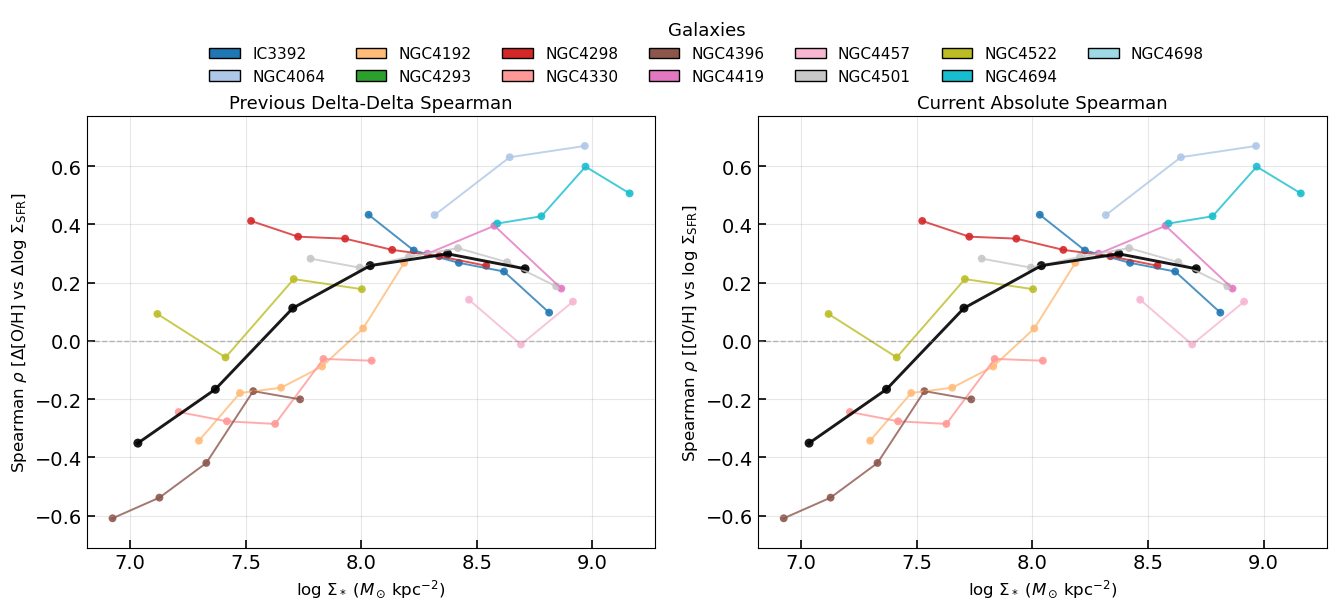

In [ ]:
# ------------------------------------------------------------------
# Comparison 1: Spearman trends
# Left  = previous Delta-Delta method (3σ unique clipping)
# Right = current absolute-value method (3σ unique clipping)
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import spearmanr
from matplotlib.patches import Patch


def load_maps_compare(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
        elif 'O_H_O3N2_M13_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")

    return sigM, sigSFR, oh_map


def calculate_binned_stats_cmp(x_data, y_data, bin_width=0.2, min_unique=20):
    x_data = np.asarray(x_data)
    y_data = np.asarray(y_data)

    finite = np.isfinite(x_data) & np.isfinite(y_data)
    if np.sum(finite) == 0:
        return np.array([]), np.array([]), np.array([]), np.array([])

    x_min, x_max = np.nanmin(x_data[finite]), np.nanmax(x_data[finite])
    if (not np.isfinite(x_min)) or (not np.isfinite(x_max)) or x_min == x_max:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    if bin_edges.size < 2:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    medians = []
    stds = []
    counts = []
    valid_centers = []

    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = finite & (x_data >= bin_start) & (x_data < bin_end)
        if np.sum(in_bin) == 0:
            continue

        y_in_bin = y_data[in_bin]
        if len(np.unique(y_in_bin)) >= min_unique:
            medians.append(np.nanmedian(y_in_bin))
            stds.append(np.nanstd(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])

    return np.array(valid_centers), np.array(medians), np.array(stds), np.array(counts)


def compute_3sigma_unique_mask_cmp(x_data, y_data, valid_mask):
    mask = np.zeros_like(valid_mask, dtype=bool)

    if np.sum(valid_mask) <= 2:
        mask[valid_mask] = True
        return mask

    try:
        x_valid = x_data[valid_mask]
        y_valid = y_data[valid_mask]

        x_unique = np.unique(x_valid)
        y_unique = np.unique(y_valid)

        x_mean = np.mean(x_unique)
        x_std = np.std(x_unique)
        y_mean = np.mean(y_unique)
        y_std = np.std(y_unique)

        if (not np.isfinite(x_std)) or (not np.isfinite(y_std)):
            mask[valid_mask] = True
            return mask

        x_lower = x_mean - 3 * x_std
        x_upper = x_mean + 3 * x_std
        y_lower = y_mean - 3 * y_std
        y_upper = y_mean + 3 * y_std

        inside = (
            (x_valid >= x_lower)
            & (x_valid <= x_upper)
            & (y_valid >= y_lower)
            & (y_valid <= y_upper)
        )
        mask[valid_mask] = inside
    except Exception:
        mask[valid_mask] = True

    return mask


def collect_spearman_previous_delta():
    all_bin_centers = []
    all_rho_values = []
    all_galaxy_indices = []

    global_sigM_list = []
    global_sigSFR_list = []
    global_oh_list = []

    bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
    galaxies_all = [f.name.split('_')[0] for f in bins]
    excluded_galaxies = {'NGC4383'}
    galaxies = [g for g in galaxies_all if g not in excluded_galaxies]

    galaxy_colors_all = plt.cm.tab20(np.linspace(0, 1, len(galaxies_all)))
    galaxy_color_dict = dict(zip(galaxies_all, galaxy_colors_all))

    for gal_index, gal in enumerate(galaxies):
        try:
            sigM, sigSFR, oh_map = load_maps_compare(gal)
        except Exception:
            continue

        valid_all = np.isfinite(sigM) & np.isfinite(sigSFR) & np.isfinite(oh_map)
        if np.sum(valid_all) == 0:
            continue

        global_sigM_list.append(sigM[valid_all].ravel())
        global_sigSFR_list.append(sigSFR[valid_all].ravel())
        global_oh_list.append(oh_map[valid_all].ravel())

        n_bins = 6
        sigmaM_min = np.nanpercentile(sigM[valid_all], 2.5)
        sigmaM_max = np.nanpercentile(sigM[valid_all], 97.5)
        sigmaM_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
        sigmaM_centers = 0.5 * (sigmaM_edges[:-1] + sigmaM_edges[1:])

        for i in range(n_bins):
            if i == 0:
                bin_mask = (sigM >= sigmaM_edges[i]) & (sigM < sigmaM_edges[i + 1]) & valid_all
            elif i == n_bins - 1:
                bin_mask = (sigM >= sigmaM_edges[i]) & (sigM <= sigmaM_edges[i + 1]) & valid_all
            else:
                bin_mask = (sigM >= sigmaM_edges[i]) & (sigM < sigmaM_edges[i + 1]) & valid_all

            if np.sum(bin_mask) <= 2:
                continue

            x_raw = sigSFR[bin_mask]
            y_raw = oh_map[bin_mask]

            x = x_raw - np.nanmean(x_raw)
            y = y_raw - np.nanmean(y_raw)

            valid_corr = np.isfinite(x) & np.isfinite(y)
            if np.sum(valid_corr) <= 2:
                continue

            sigma_mask = compute_3sigma_unique_mask_cmp(x, y, valid_corr)

            x_trend = x[sigma_mask]
            y_trend = y[sigma_mask]
            centers, medians, stds, counts = calculate_binned_stats_cmp(x_trend, y_trend, bin_width=0.2, min_unique=20)
            has_trend = centers.size >= 2

            if has_trend and np.sum(sigma_mask & valid_corr) > 2:
                try:
                    rho, pval = spearmanr(x[sigma_mask & valid_corr], y[sigma_mask & valid_corr])
                except Exception:
                    rho = np.nan
            else:
                rho = np.nan

            if np.isfinite(rho):
                all_bin_centers.append(sigmaM_centers[i])
                all_rho_values.append(rho)
                all_galaxy_indices.append(gal_index)

    global_bin_centers = []
    global_rho_values = []

    if len(global_sigM_list) > 0:
        global_sigM = np.concatenate(global_sigM_list)
        global_sigSFR = np.concatenate(global_sigSFR_list)
        global_oh = np.concatenate(global_oh_list)

        n_bins_global = 6
        sigmaM_min_g = np.nanpercentile(global_sigM, 2.5)
        sigmaM_max_g = np.nanpercentile(global_sigM, 97.5)
        sigmaM_edges_g = np.linspace(sigmaM_min_g, sigmaM_max_g, n_bins_global + 1)
        sigmaM_centers_g = 0.5 * (sigmaM_edges_g[:-1] + sigmaM_edges_g[1:])

        for i in range(n_bins_global):
            if i == 0:
                bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM < sigmaM_edges_g[i + 1])
            elif i == n_bins_global - 1:
                bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM <= sigmaM_edges_g[i + 1])
            else:
                bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM < sigmaM_edges_g[i + 1])

            if np.sum(bin_mask_g) <= 2:
                continue

            x_raw_g = global_sigSFR[bin_mask_g]
            y_raw_g = global_oh[bin_mask_g]

            x_g = x_raw_g - np.nanmean(x_raw_g)
            y_g = y_raw_g - np.nanmean(y_raw_g)

            valid_corr_g = np.isfinite(x_g) & np.isfinite(y_g)
            if np.sum(valid_corr_g) <= 2:
                continue

            sigma_mask_g = compute_3sigma_unique_mask_cmp(x_g, y_g, valid_corr_g)
            x_trend_g = x_g[sigma_mask_g]
            y_trend_g = y_g[sigma_mask_g]

            centers_g, medians_g, stds_g, counts_g = calculate_binned_stats_cmp(x_trend_g, y_trend_g, bin_width=0.2, min_unique=20)
            has_trend_g = centers_g.size >= 3

            if has_trend_g and np.sum(sigma_mask_g & valid_corr_g) > 2:
                try:
                    rho_g, p_g = spearmanr(x_g[sigma_mask_g & valid_corr_g], y_g[sigma_mask_g & valid_corr_g])
                    global_bin_centers.append(sigmaM_centers_g[i])
                    global_rho_values.append(rho_g)
                except Exception:
                    pass

    return {
        'galaxies': galaxies,
        'galaxy_color_dict': galaxy_color_dict,
        'all_bin_centers': np.array(all_bin_centers),
        'all_rho_values': np.array(all_rho_values),
        'all_galaxy_indices': np.array(all_galaxy_indices),
        'global_bin_centers': np.array(global_bin_centers),
        'global_rho_values': np.array(global_rho_values),
    }


def collect_spearman_current_absolute():
    all_bin_centers = []
    all_rho_values = []
    all_galaxy_indices = []

    global_sigM_list = []
    global_sigSFR_list = []
    global_oh_list = []

    bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
    galaxies_all = [f.name.split('_')[0] for f in bins]
    excluded_galaxies = {'NGC4383'}
    galaxies = [g for g in galaxies_all if g not in excluded_galaxies]

    galaxy_colors_all = plt.cm.tab20(np.linspace(0, 1, len(galaxies_all)))
    galaxy_color_dict = dict(zip(galaxies_all, galaxy_colors_all))

    for gal_index, gal in enumerate(galaxies):
        try:
            sigM, sigSFR, oh_map = load_maps_compare(gal)
        except Exception:
            continue

        valid_all = np.isfinite(sigM) & np.isfinite(sigSFR) & np.isfinite(oh_map)
        if np.sum(valid_all) == 0:
            continue

        global_sigM_list.append(sigM[valid_all].ravel())
        global_sigSFR_list.append(sigSFR[valid_all].ravel())
        global_oh_list.append(oh_map[valid_all].ravel())

        n_bins = 6
        sigmaM_min = np.nanpercentile(sigM[valid_all], 2.5)
        sigmaM_max = np.nanpercentile(sigM[valid_all], 97.5)
        sigmaM_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
        sigmaM_centers = 0.5 * (sigmaM_edges[:-1] + sigmaM_edges[1:])

        for i in range(n_bins):
            if i == 0:
                bin_mask = (sigM >= sigmaM_edges[i]) & (sigM < sigmaM_edges[i + 1]) & valid_all
            elif i == n_bins - 1:
                bin_mask = (sigM >= sigmaM_edges[i]) & (sigM <= sigmaM_edges[i + 1]) & valid_all
            else:
                bin_mask = (sigM >= sigmaM_edges[i]) & (sigM < sigmaM_edges[i + 1]) & valid_all

            if np.sum(bin_mask) <= 2:
                continue

            x = sigSFR[bin_mask]
            y = oh_map[bin_mask]

            valid_corr = np.isfinite(x) & np.isfinite(y)
            if np.sum(valid_corr) <= 2:
                continue

            sigma_mask = compute_3sigma_unique_mask_cmp(x, y, valid_corr)

            x_trend = x[sigma_mask]
            y_trend = y[sigma_mask]
            centers, medians, stds, counts = calculate_binned_stats_cmp(x_trend, y_trend, bin_width=0.2, min_unique=20)
            has_trend = centers.size >= 2

            if has_trend and np.sum(sigma_mask & valid_corr) > 2:
                try:
                    rho, pval = spearmanr(x[sigma_mask & valid_corr], y[sigma_mask & valid_corr])
                except Exception:
                    rho = np.nan
            else:
                rho = np.nan

            if np.isfinite(rho):
                all_bin_centers.append(sigmaM_centers[i])
                all_rho_values.append(rho)
                all_galaxy_indices.append(gal_index)

    global_bin_centers = []
    global_rho_values = []

    if len(global_sigM_list) > 0:
        global_sigM = np.concatenate(global_sigM_list)
        global_sigSFR = np.concatenate(global_sigSFR_list)
        global_oh = np.concatenate(global_oh_list)

        n_bins_global = 6
        sigmaM_min_g = np.nanpercentile(global_sigM, 2.5)
        sigmaM_max_g = np.nanpercentile(global_sigM, 97.5)
        sigmaM_edges_g = np.linspace(sigmaM_min_g, sigmaM_max_g, n_bins_global + 1)
        sigmaM_centers_g = 0.5 * (sigmaM_edges_g[:-1] + sigmaM_edges_g[1:])

        for i in range(n_bins_global):
            if i == 0:
                bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM < sigmaM_edges_g[i + 1])
            elif i == n_bins_global - 1:
                bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM <= sigmaM_edges_g[i + 1])
            else:
                bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM < sigmaM_edges_g[i + 1])

            if np.sum(bin_mask_g) <= 2:
                continue

            x_g = global_sigSFR[bin_mask_g]
            y_g = global_oh[bin_mask_g]

            valid_corr_g = np.isfinite(x_g) & np.isfinite(y_g)
            if np.sum(valid_corr_g) <= 2:
                continue

            sigma_mask_g = compute_3sigma_unique_mask_cmp(x_g, y_g, valid_corr_g)
            x_trend_g = x_g[sigma_mask_g]
            y_trend_g = y_g[sigma_mask_g]

            centers_g, medians_g, stds_g, counts_g = calculate_binned_stats_cmp(x_trend_g, y_trend_g, bin_width=0.2, min_unique=20)
            has_trend_g = centers_g.size >= 3

            if has_trend_g and np.sum(sigma_mask_g & valid_corr_g) > 2:
                try:
                    rho_g, p_g = spearmanr(x_g[sigma_mask_g & valid_corr_g], y_g[sigma_mask_g & valid_corr_g])
                    global_bin_centers.append(sigmaM_centers_g[i])
                    global_rho_values.append(rho_g)
                except Exception:
                    pass

    return {
        'galaxies': galaxies,
        'galaxy_color_dict': galaxy_color_dict,
        'all_bin_centers': np.array(all_bin_centers),
        'all_rho_values': np.array(all_rho_values),
        'all_galaxy_indices': np.array(all_galaxy_indices),
        'global_bin_centers': np.array(global_bin_centers),
        'global_rho_values': np.array(global_rho_values),
    }


def plot_spearman_panel(ax, result, y_label, panel_title):
    all_bin_centers = result['all_bin_centers']
    all_rho_values = result['all_rho_values']
    all_galaxy_indices = result['all_galaxy_indices']
    galaxies = result['galaxies']
    galaxy_color_dict = result['galaxy_color_dict']

    if all_rho_values.size > 0:
        unique_idx = np.unique(all_galaxy_indices)
        for idx in unique_idx:
            mask = all_galaxy_indices == idx
            x_vals = all_bin_centers[mask]
            y_vals = all_rho_values[mask]
            if x_vals.size <= 1:
                continue

            order = np.argsort(x_vals)
            gal_name = galaxies[idx]
            color = galaxy_color_dict[gal_name]
            ax.plot(x_vals[order], y_vals[order], color=color, linewidth=1.4, alpha=0.8)
            ax.scatter(x_vals[order], y_vals[order], color=color, s=32, alpha=0.9, edgecolors='none', rasterized=True)

    if result['global_rho_values'].size > 0:
        order_g = np.argsort(result['global_bin_centers'])
        ax.plot(result['global_bin_centers'][order_g], result['global_rho_values'][order_g],
                color='black', linewidth=2.1, alpha=0.9)
        ax.scatter(result['global_bin_centers'][order_g], result['global_rho_values'][order_g],
                   color='black', s=42, alpha=0.9, edgecolors='none', rasterized=True)

    ax.axhline(0.0, color='gray', linestyle='--', linewidth=1.0, alpha=0.5)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel(r'$\log\,\Sigma_*\;(M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
    ax.set_ylabel(y_label, fontsize=12)
    ax.set_title(panel_title, fontsize=13)


res_delta_previous = collect_spearman_previous_delta()
res_abs_current = collect_spearman_current_absolute()

fig = plt.figure(figsize=(16, 7))
gs = gridspec.GridSpec(2, 2, height_ratios=[0.2, 1.0], hspace=0.08, wspace=0.18)
legend_ax = fig.add_subplot(gs[0, :])
ax_left = fig.add_subplot(gs[1, 0])
ax_right = fig.add_subplot(gs[1, 1])
legend_ax.axis('off')

plot_spearman_panel(
    ax_left,
    res_delta_previous,
    r'Spearman $\rho$ [Δ[O/H] vs Δ$\log\,\Sigma_{\mathrm{SFR}}$]',
    'Previous Delta-Delta Spearman',
)
plot_spearman_panel(
    ax_right,
    res_abs_current,
    r'Spearman $\rho$ [[O/H] vs $\log\,\Sigma_{\mathrm{SFR}}$]',
    'Current Absolute Spearman',
)

rho_pool = []
if res_delta_previous['all_rho_values'].size > 0:
    rho_pool.append(res_delta_previous['all_rho_values'])
if res_delta_previous['global_rho_values'].size > 0:
    rho_pool.append(res_delta_previous['global_rho_values'])
if res_abs_current['all_rho_values'].size > 0:
    rho_pool.append(res_abs_current['all_rho_values'])
if res_abs_current['global_rho_values'].size > 0:
    rho_pool.append(res_abs_current['global_rho_values'])

if len(rho_pool) > 0:
    all_rho = np.concatenate(rho_pool)
    y_min = np.nanmin(all_rho)
    y_max = np.nanmax(all_rho)
    if np.isfinite(y_min) and np.isfinite(y_max):
        pad = max(0.05, 0.08 * (y_max - y_min + 1e-8))
        ax_left.set_ylim(y_min - pad, y_max + pad)
        ax_right.set_ylim(y_min - pad, y_max + pad)

legend_names = sorted(set(res_delta_previous['galaxies']).union(set(res_abs_current['galaxies'])))
legend_elements = [
    Patch(facecolor=res_abs_current['galaxy_color_dict'][gal], edgecolor='black', label=gal)
    for gal in legend_names
]
if len(legend_elements) > 0:
    legend_ax.legend(handles=legend_elements, loc='center', ncol=min(len(legend_elements), 7),
                     frameon=False, fontsize=11, title='Galaxies', title_fontsize=13)

plt.show()

In [ ]:
# ------------------------------------------------------------------
# Comparison 2: 2x4 map comparison for NGC4501
# Left 2x2  = previous Delta maps
# Right 2x2 = current Absolute maps
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, SymLogNorm
import matplotlib.ticker as mticker
from mpl_toolkits.axes_grid1 import make_axes_locatable


def load_maps_for_2x4(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        binid_map = h_spatial['BINID'].data
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
        elif 'O_H_O3N2_M13_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
        gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header

    return sigM, sigSFR, oh_map, gas_header, binid_map


def local_bivariate_moran_by_bin(A, B, valid_mask, binid_map, neighbourhood='queen'):
    """Local bivariate Moran-style statistic on adjacent spatial bins.

    Each valid BINID is treated as one graph node, using the mean A and B value
    of that bin. The resulting per-bin Moran value is expanded back to all
    valid pixels in the bin for plotting.
    """
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)
    valid_mask = np.asarray(valid_mask, dtype=bool)
    binid_raw = np.asarray(binid_map, dtype=float)
    if A.shape != B.shape or A.shape != valid_mask.shape or A.shape != binid_raw.shape:
        raise ValueError('A, B, valid_mask, and binid_map must have the same shape')

    I_map = np.full(A.shape, np.nan)
    quad_map = np.zeros(A.shape, dtype=np.int16)
    finite_bin = np.isfinite(binid_raw) & (binid_raw >= 0)
    binid = np.full(A.shape, -1, dtype=np.int64)
    binid[finite_bin] = np.rint(binid_raw[finite_bin]).astype(np.int64)
    valid = valid_mask & np.isfinite(A) & np.isfinite(B) & (binid >= 0)
    valid_bins = np.unique(binid[valid])
    if valid_bins.size < 2:
        return I_map, quad_map

    max_bin = int(valid_bins.max())
    flat_bins = binid[valid].ravel()
    counts = np.bincount(flat_bins, minlength=max_bin + 1).astype(float)
    sum_A = np.bincount(flat_bins, weights=A[valid].ravel(), minlength=max_bin + 1)
    sum_B = np.bincount(flat_bins, weights=B[valid].ravel(), minlength=max_bin + 1)
    A_bin = np.full(max_bin + 1, np.nan)
    B_bin = np.full(max_bin + 1, np.nan)
    has_data = counts > 0
    A_bin[has_data] = sum_A[has_data] / counts[has_data]
    B_bin[has_data] = sum_B[has_data] / counts[has_data]

    A_vals = A_bin[valid_bins]
    B_vals = B_bin[valid_bins]
    A_std = np.nanstd(A_vals)
    B_std = np.nanstd(B_vals)
    if not np.isfinite(A_std) or not np.isfinite(B_std) or A_std == 0 or B_std == 0:
        return I_map, quad_map

    Az = np.full(max_bin + 1, np.nan)
    Bz = np.full(max_bin + 1, np.nan)
    Az[valid_bins] = (A_vals - np.nanmean(A_vals)) / A_std
    Bz[valid_bins] = (B_vals - np.nanmean(B_vals)) / B_std

    offsets = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    if neighbourhood == 'queen':
        offsets += [(-1, -1), (-1, 1), (1, -1), (1, 1)]
    elif neighbourhood != 'rook':
        raise ValueError("neighbourhood must be 'rook' or 'queen'")

    adjacency = {int(b): set() for b in valid_bins}
    rows, cols = A.shape
    for dy, dx in offsets:
        y0 = max(0, -dy)
        y1 = rows - max(0, dy)
        x0 = max(0, -dx)
        x1 = cols - max(0, dx)
        src = (slice(y0, y1), slice(x0, x1))
        dst = (slice(y0 + dy, y1 + dy), slice(x0 + dx, x1 + dx))
        pair_valid = valid[src] & valid[dst] & (binid[src] != binid[dst])
        for left, right in zip(binid[src][pair_valid], binid[dst][pair_valid]):
            left = int(left)
            right = int(right)
            adjacency[left].add(right)
            adjacency[right].add(left)

    for b in valid_bins:
        b = int(b)
        neigh = sorted(adjacency[b])
        if not neigh:
            continue
        lag_B = np.nanmean(Bz[neigh])
        I_val = Az[b] * lag_B
        pixels = valid & (binid == b)
        I_map[pixels] = I_val
        if Az[b] >= 0 and lag_B >= 0:
            quad_map[pixels] = 1
        elif Az[b] < 0 and lag_B < 0:
            quad_map[pixels] = 2
        elif Az[b] >= 0 and lag_B < 0:
            quad_map[pixels] = 3
        else:
            quad_map[pixels] = 4

    return I_map, quad_map
def add_cbar(fig, ax, im, label, size='3%', pad=0.02, labelsize=9):
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size=size, pad=pad)
    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label(label, fontsize=labelsize)
    cbar.ax.tick_params(labelsize=8)
    return cbar


def add_scalebar(ax, length_deg, label='1 kpc'):
    x0, x1 = ax.get_xlim()
    x_range = abs(x1 - x0)
    if x_range == 0:
        return

    frac_len = length_deg / x_range
    x_start = 0.05
    y_start = 0.95
    x_end = x_start + frac_len

    line, = ax.plot([x_start, x_end], [y_start, y_start], transform=ax.transAxes,
                    color='k', lw=2.5, clip_on=False)
    line.set_in_layout(False)
    txt = ax.text((x_start + x_end) / 2, y_start - 0.03, label,
                  transform=ax.transAxes, ha='center', va='top', color='k', fontsize=9)
    txt.set_in_layout(False)


def plot_delta_vs_absolute_2x4(gal='NGC4501', threshold=1, n_bins=12):
    sigM, sigSFR, oh_map, gas_header, binid_map = load_maps_for_2x4(gal)
    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_map)
    valid_sigM = np.isfinite(sigM)
    valid_all = valid_sfr & valid_oh & valid_sigM

    sigmaM_min = np.nanmin(sigM[valid_all])
    sigmaM_max = np.nanmax(sigM[valid_all])
    sigmaM_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)

    sfr_offset = np.full_like(sigSFR, np.nan)
    oh_offset = np.full_like(oh_map, np.nan)
    sigM_binned_map = np.full_like(sigM, np.nan)

    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_edges[i]) & (sigM < sigmaM_edges[i + 1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_edges[i]) & (sigM <= sigmaM_edges[i + 1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_edges[i]) & (sigM < sigmaM_edges[i + 1]) & valid_all

        if np.sum(bin_mask) > 0:
            sfr_mean = np.mean(sigSFR[bin_mask])
            oh_mean = np.mean(oh_map[bin_mask])
            sfr_offset[bin_mask] = sigSFR[bin_mask] - sfr_mean
            oh_offset[bin_mask] = oh_map[bin_mask] - oh_mean

            bin_center = (sigmaM_edges[i] + sigmaM_edges[i + 1]) / 2
            sigM_binned_map[bin_mask] = bin_center

    I_delta, _ = local_bivariate_moran_by_bin(sfr_offset, oh_offset, valid_all, binid_map, neighbourhood='queen')
    I_abs, _ = local_bivariate_moran_by_bin(sigSFR, oh_map, valid_all, binid_map, neighbourhood='queen')

    # Statistics for the Moran-like text boxes in the bottom-left panels
    valid_I_delta = np.isfinite(I_delta)
    n_total_delta = np.sum(valid_I_delta)
    n_high_delta = np.sum(I_delta[valid_I_delta] > threshold)
    n_mid_delta = np.sum((I_delta[valid_I_delta] >= -threshold) & (I_delta[valid_I_delta] <= threshold))
    n_low_delta = np.sum(I_delta[valid_I_delta] < -threshold)
    pct_high_delta = (n_high_delta / n_total_delta * 100) if n_total_delta > 0 else 0
    pct_mid_delta = (n_mid_delta / n_total_delta * 100) if n_total_delta > 0 else 0
    pct_low_delta = (n_low_delta / n_total_delta * 100) if n_total_delta > 0 else 0

    valid_I_abs = np.isfinite(I_abs)
    n_total_abs = np.sum(valid_I_abs)
    n_high_abs = np.sum(I_abs[valid_I_abs] > threshold)
    n_mid_abs = np.sum((I_abs[valid_I_abs] >= -threshold) & (I_abs[valid_I_abs] <= threshold))
    n_low_abs = np.sum(I_abs[valid_I_abs] < -threshold)
    pct_high_abs = (n_high_abs / n_total_abs * 100) if n_total_abs > 0 else 0
    pct_mid_abs = (n_mid_abs / n_total_abs * 100) if n_total_abs > 0 else 0
    pct_low_abs = (n_low_abs / n_total_abs * 100) if n_total_abs > 0 else 0

    wcs_celestial = WCS(gas_header).celestial
    y_size, x_size = sigSFR.shape
    xx, yy = np.meshgrid(np.arange(x_size), np.arange(y_size))
    ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
    extent = [ra.max(), ra.min(), dec.min(), dec.max()]

    pix_scale_arcsec = 0.2
    distance_mpc = 16.5
    kpc_arcsec = 206265.0 / (distance_mpc * 1000.0)
    scalebar_length_deg = kpc_arcsec / 3600.0

    sfr_off_max = np.nanmax(np.abs(sfr_offset[valid_all]))
    oh_off_max = np.nanmax(np.abs(oh_offset[valid_all]))
    sfr_abs_min, sfr_abs_max = np.nanmin(sigSFR[valid_sfr]), np.nanmax(sigSFR[valid_sfr])
    oh_abs_min, oh_abs_max = np.nanmin(oh_map[valid_oh]), np.nanmax(oh_map[valid_oh])

    vI_delta = np.nanmax(np.abs(I_delta[np.isfinite(I_delta)])) if np.any(np.isfinite(I_delta)) else 1.0
    vI_abs = np.nanmax(np.abs(I_abs[np.isfinite(I_abs)])) if np.any(np.isfinite(I_abs)) else 1.0
    if (not np.isfinite(vI_delta)) or vI_delta == 0:
        vI_delta = 1.0
    if (not np.isfinite(vI_abs)) or vI_abs == 0:
        vI_abs = 1.0

    cmap_discrete = plt.cm.inferno
    norm_discrete = BoundaryNorm(sigmaM_edges, cmap_discrete.N)

    fig, axs = plt.subplots(2, 4, figsize=(22, 10), sharex=True, sharey=True)
    fig.subplots_adjust(left=0.05, right=0.98, bottom=0.07, top=0.92, wspace=0.18, hspace=0.08)

    for ax in axs.ravel():
        ax.xaxis.set_major_locator(mticker.MaxNLocator(3))
        ax.yaxis.set_major_locator(mticker.MaxNLocator(5))
        ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

    # Previous (Delta) block
    im00 = axs[0, 0].imshow(np.ma.masked_invalid(sfr_offset), origin='lower', cmap='coolwarm',
                            extent=extent, vmin=-sfr_off_max, vmax=sfr_off_max, aspect='equal')
    add_cbar(fig, axs[0, 0], im00, r'$\Delta\log\,\Sigma_{\mathrm{SFR}}$')

    im01 = axs[0, 1].imshow(np.ma.masked_invalid(oh_offset), origin='lower', cmap='coolwarm',
                            extent=extent, vmin=-oh_off_max, vmax=oh_off_max, aspect='equal')
    add_cbar(fig, axs[0, 1], im01, r'$\Delta$[O/H]')

    norm_delta = SymLogNorm(linthresh=threshold, linscale=1.0, vmin=-vI_delta, vmax=vI_delta, base=10)
    im10 = axs[1, 0].imshow(np.ma.masked_invalid(I_delta), origin='lower', cmap='coolwarm',
                            extent=extent, norm=norm_delta, aspect='equal')
    add_cbar(fig, axs[1, 0], im10, r'$z(\Delta\log\Sigma_{\rm SFR})\times z_{\rm lag}(\Delta{\rm [O/H]})$')

    im11 = axs[1, 1].imshow(np.ma.masked_invalid(sigM_binned_map), origin='lower', cmap=cmap_discrete,
                            norm=norm_discrete, extent=extent, aspect='equal')
    cbar11 = add_cbar(fig, axs[1, 1], im11, r'$\log\,\Sigma_*$')
    centers = [(sigmaM_edges[i] + sigmaM_edges[i + 1]) / 2 for i in range(n_bins)]
    cbar11.set_ticks(centers)
    cbar11.set_ticklabels([f'{c:.2f}' for c in centers])

    # Current (Absolute) block
    im02 = axs[0, 2].imshow(np.ma.masked_invalid(sigSFR), origin='lower', cmap='coolwarm',
                            extent=extent, vmin=sfr_abs_min, vmax=sfr_abs_max, aspect='equal')
    add_cbar(fig, axs[0, 2], im02, r'$\log\,\Sigma_{\mathrm{SFR}}$')

    im03 = axs[0, 3].imshow(np.ma.masked_invalid(oh_map), origin='lower', cmap='coolwarm',
                            extent=extent, vmin=oh_abs_min, vmax=oh_abs_max, aspect='equal')
    add_cbar(fig, axs[0, 3], im03, r'[O/H]')

    norm_abs = SymLogNorm(linthresh=threshold, linscale=1.0, vmin=-vI_abs, vmax=vI_abs, base=10)
    im12 = axs[1, 2].imshow(np.ma.masked_invalid(I_abs), origin='lower', cmap='coolwarm',
                            extent=extent, norm=norm_abs, aspect='equal')
    add_cbar(fig, axs[1, 2], im12, r'$z(\log\Sigma_{\rm SFR})\times z_{\rm lag}({\rm [O/H]})$')

    im13 = axs[1, 3].imshow(np.ma.masked_invalid(sigM_binned_map), origin='lower', cmap=cmap_discrete,
                            norm=norm_discrete, extent=extent, aspect='equal')
    cbar13 = add_cbar(fig, axs[1, 3], im13, r'$\log\,\Sigma_*$')
    cbar13.set_ticks(centers)
    cbar13.set_ticklabels([f'{c:.2f}' for c in centers])

    axs[0, 0].set_title('Δlog Σ_SFR', fontsize=12)
    axs[0, 1].set_title('Δ[O/H]', fontsize=12)
    axs[1, 0].set_title('Moran-like (Delta)', fontsize=12)
    axs[1, 1].set_title('Binned Σ*', fontsize=12)

    axs[0, 2].set_title('log Σ_SFR', fontsize=12)
    axs[0, 3].set_title('[O/H]', fontsize=12)
    axs[1, 2].set_title('Moran-like (Absolute)', fontsize=12)
    axs[1, 3].set_title('Binned Σ*', fontsize=12)

    fig.text(0.25, 0.96, f'{gal}: Previous (Delta)', ha='center', va='center', fontsize=14, fontweight='bold')
    fig.text(0.75, 0.96, f'{gal}: Current (Absolute)', ha='center', va='center', fontsize=14, fontweight='bold')

    legend_text_delta = (
        rf'$I_i > {threshold}$: {pct_high_delta:.1f}% (N={n_high_delta})'
        '\n' + rf'$|I_i| \leq {threshold}$: {pct_mid_delta:.1f}% (N={n_mid_delta})'
        '\n' + rf'$I_i < -{threshold}$: {pct_low_delta:.1f}% (N={n_low_delta})'
    )
    axs[1, 0].text(
        0.98, 0.02, legend_text_delta, transform=axs[1, 0].transAxes,
        fontsize=9, va='bottom', ha='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.85)
    )

    legend_text_abs = (
        rf'$I_i > {threshold}$: {pct_high_abs:.1f}% (N={n_high_abs})'
        '\n' + rf'$|I_i| \leq {threshold}$: {pct_mid_abs:.1f}% (N={n_mid_abs})'
        '\n' + rf'$I_i < -{threshold}$: {pct_low_abs:.1f}% (N={n_low_abs})'
    )
    axs[1, 2].text(
        0.98, 0.02, legend_text_abs, transform=axs[1, 2].transAxes,
        fontsize=9, va='bottom', ha='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.85)
    )

    add_scalebar(axs[0, 0], scalebar_length_deg, label='1 kpc')
    add_scalebar(axs[0, 2], scalebar_length_deg, label='1 kpc')

    for ax in axs[0, :]:
        plt.setp(ax.get_xticklabels(), visible=False)

    for ax in [axs[0, 1], axs[0, 2], axs[0, 3], axs[1, 1], axs[1, 2], axs[1, 3]]:
        plt.setp(ax.get_yticklabels(), visible=False)

    axs[1, 0].set_xlabel('RA (deg)', fontsize=12)
    axs[1, 1].set_xlabel('RA (deg)', fontsize=12)
    axs[1, 2].set_xlabel('RA (deg)', fontsize=12)
    axs[1, 3].set_xlabel('RA (deg)', fontsize=12)

    axs[0, 0].set_ylabel('Dec (deg)', fontsize=12)
    axs[1, 0].set_ylabel('Dec (deg)', fontsize=12)

    plt.show()


plot_delta_vs_absolute_2x4('NGC4501', threshold=1, n_bins=12)

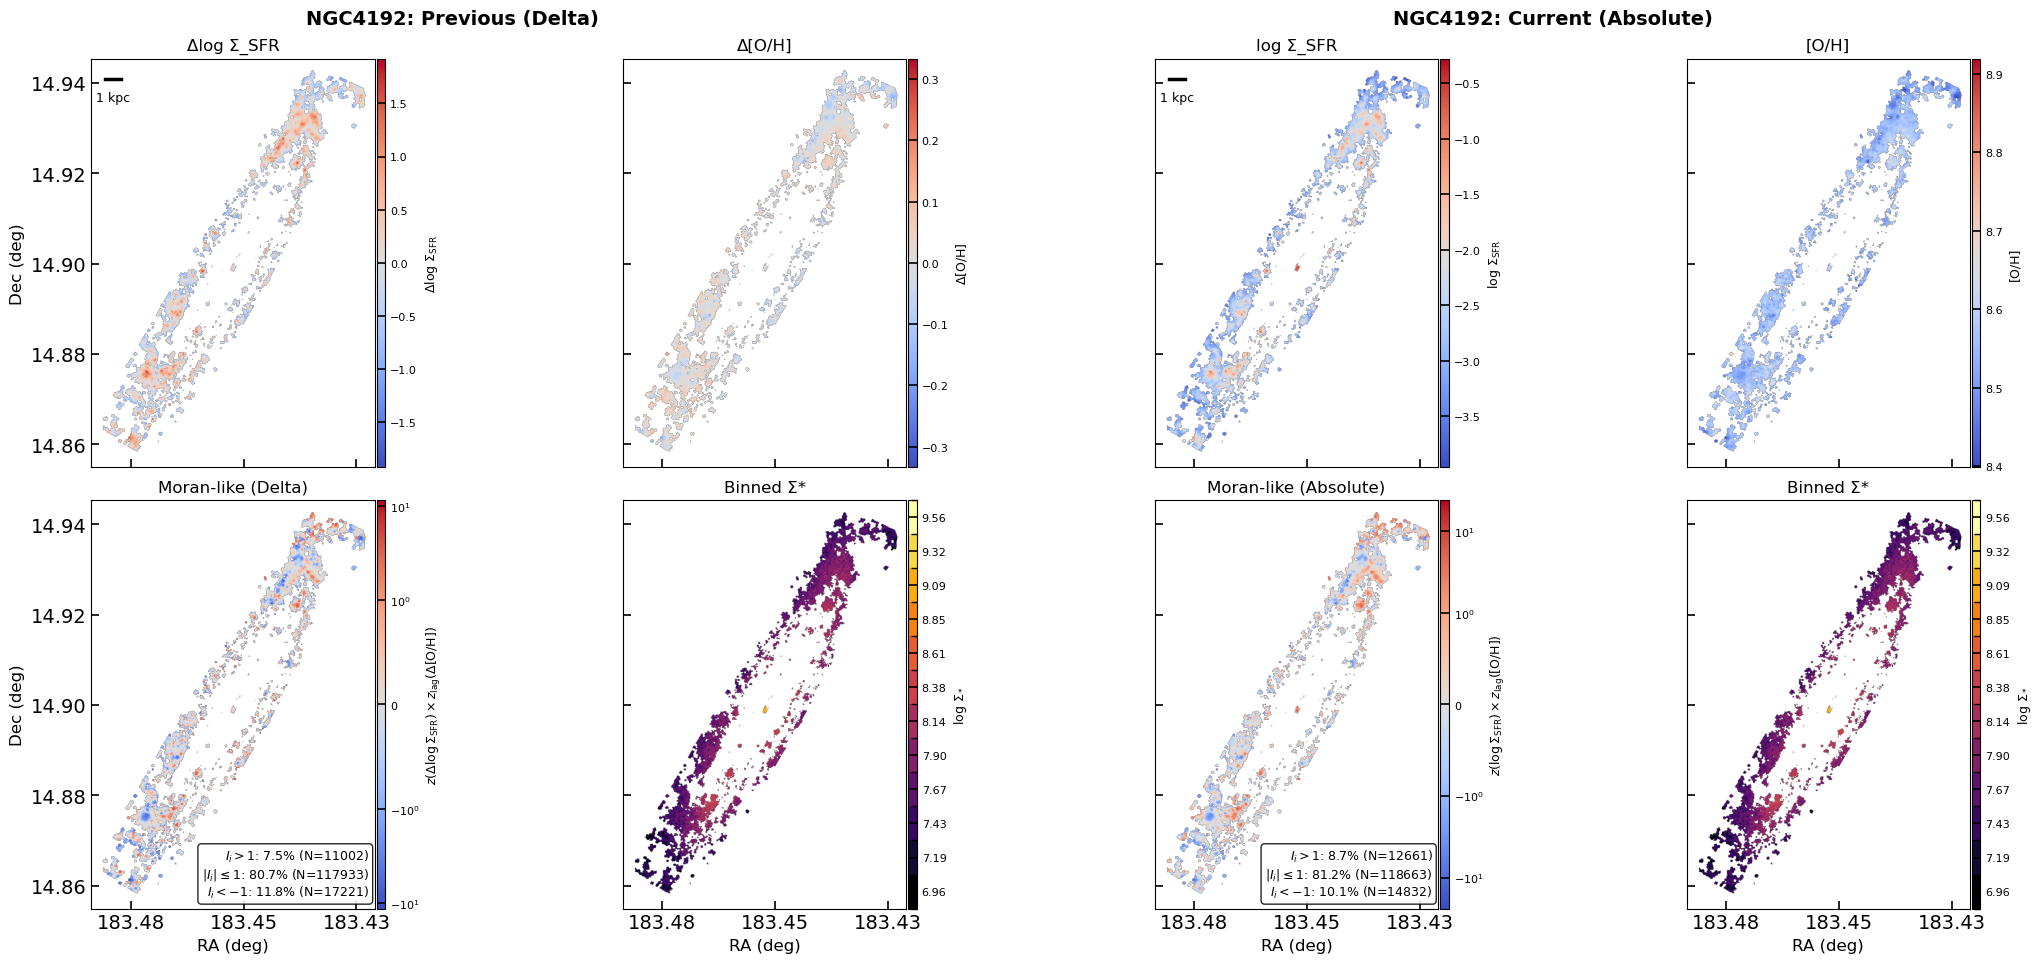

In [ ]:
# ------------------------------------------------------------------
# Comparison 3: 2x4 map comparison for NGC4192
# Left 2x2  = previous Delta maps
# Right 2x2 = current Absolute maps
# ------------------------------------------------------------------
plot_delta_vs_absolute_2x4('NGC4192', threshold=1, n_bins=12)